## Assignment 2

In [26]:
import matplotlib.pyplot as plt
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.losses import MeanAbsoluteError
from keras.regularizers import l2
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping

In [11]:
(inputs, target), (x_test, y_test) = keras.datasets.california_housing.load_data(
    version="large", path="california_housing.npz", test_split=0.2
)

print(inputs.shape, target.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [15]:
# Extract sets for training and validation\n",
x_train = inputs[:13210]
y_train = target[:13210]
x_val = inputs[13210:]
y_val = target[13210:]

In [16]:
mean = x_train.mean(axis=0) # mean and standard deviation computed from training set only\n",
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

In [17]:
# define the model architecture
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
    ])

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

I0000 00:00:1774710543.804235   15397 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2b:00.0, compute capability: 8.6


In [18]:
history = model.fit(x_train, y_train, epochs=250, batch_size=32, validation_data=(x_val, y_val), verbose=0)

Epoch 1/250


I0000 00:00:1774710551.187989   15521 service.cc:153] XLA service 0x72ba18030c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774710551.188041   15521 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774710551.221658   15521 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774710551.324154   15521 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774710551.336073   15521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1272__.9
I0000 00:00:1774710551.598130   15521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I000

 90/413 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2955 - mae: 1.1309

I0000 00:00:1774710553.055273   15521 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


395/413 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2173 - mae: 0.7693

I0000 00:00:1774710553.884491   15521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1272__.9
I0000 00:00:1774710553.889832   15521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774710554.202442   15688 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 76 bytes spill stores, 76 bytes spill loads

I0000 00:00:1774710554.280399   15521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774710554.560070   15683 subprocess_compilation.cc:348] ptxas warning : Registers are spilled 

413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.6687 - mae: 0.5688 - val_loss: 0.4216 - val_mae: 0.4884
Epoch 2/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3737 - mae: 0.4358 - val_loss: 0.3692 - val_mae: 0.4258
Epoch 3/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3489 - mae: 0.4197 - val_loss: 0.3529 - val_mae: 0.4136
Epoch 4/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3337 - mae: 0.4070 - val_loss: 0.3380 - val_mae: 0.4098
Epoch 5/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3237 - mae: 0.3998 - val_loss: 0.3338 - val_mae: 0.3938
Epoch 6/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3093 - mae: 0.3877 - val_loss: 0.3378 - val_mae: 0.3915
Epoch 7/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3086 - mae: 0.3886 - val_loss: 0.3148 - val_mae: 0.3827
Epoch 8/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3021 - mae: 0.3824 - val_loss: 0.3179 - val_mae: 0.3920
Epoch 9/250
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss:

Text(0, 0.5, 'Loss')

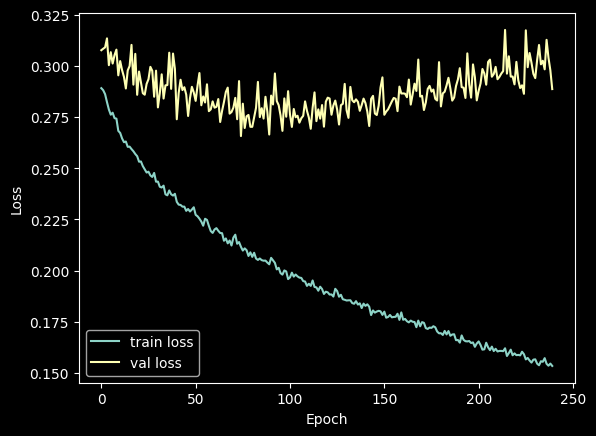

In [19]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

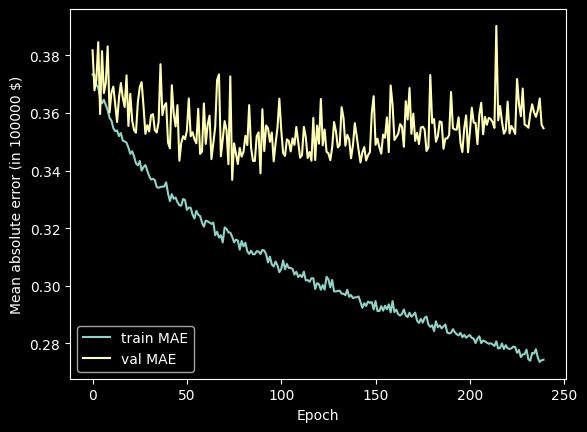

In [20]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

In [28]:
x_train_full = np.concatenate((x_train, x_val), axis=0) # join train + val sets
y_train_full = np.concatenate((y_train, y_val), axis=0)

model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
    ])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train_full, y_train_full, epochs=50, batch_size=32, verbose=0)

Epoch 1/50


I0000 00:00:1774711395.641772   15520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_631472__.8


516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6214 - mae: 0.5428
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3766 - mae: 0.4362
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3563 - mae: 0.4233
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3432 - mae: 0.4126
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3326 - mae: 0.4038
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3227 - mae: 0.3971
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3108 - mae: 0.3870
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3024 - mae: 0.3811
Epoch 9/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2976 - mae: 0.3774
Epoch 10/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2952 - mae: 0.3759
Epoch 11/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2901 - mae: 0.3703
Epoch 12/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2857 - mae: 0.3681
Epoch 13/50
516/516 ━━━━━━━━━━━━━━━━

In [24]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2800 - mae: 0.3551
Test mean absolute error: 0.3551


In [25]:
y_pred_baseline = np.full_like(y_test, np.mean(y_train_full, axis=0))
mae_fn = MeanAbsoluteError()
mae_baseline = mae_fn(y_test, y_pred_baseline).numpy()
print(f'Mean baseline MAE: {mae_baseline:.4f}')

Mean baseline MAE: 0.9059


In [35]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774711980.007971   15521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_842965__.12
I0000 00:00:1774711981.394283   15523 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_842965__.12


Text(0, 0.5, 'Loss')

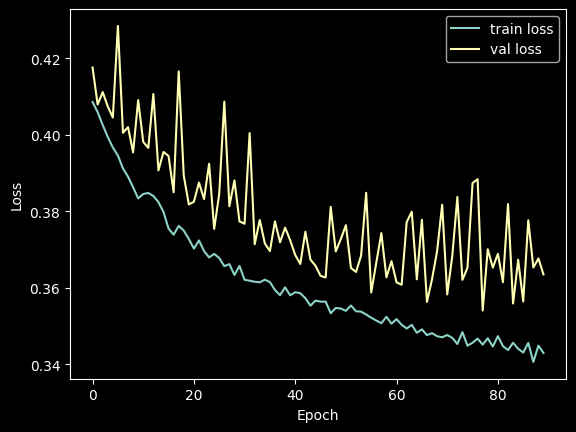

In [36]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

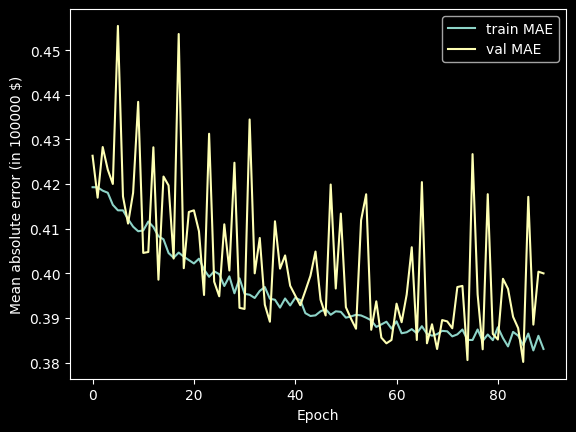

In [37]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

In [ ]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

In [38]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dropout(0.2), # drop 20% of the outputs
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774712273.062309   15523 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1053854__.11
I0000 00:00:1774712273.163529   15523 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774712273.424144   63565 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 28 bytes spill stores, 28 bytes spill loads

I0000 00:00:1774712273.475198   63555 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1774712273.701696   15523 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain

Text(0, 0.5, 'Loss')

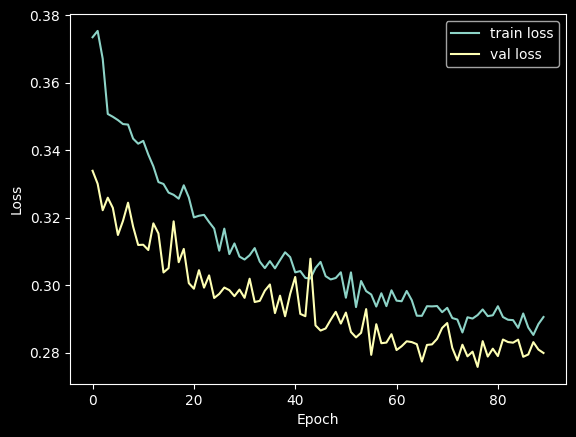

In [39]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

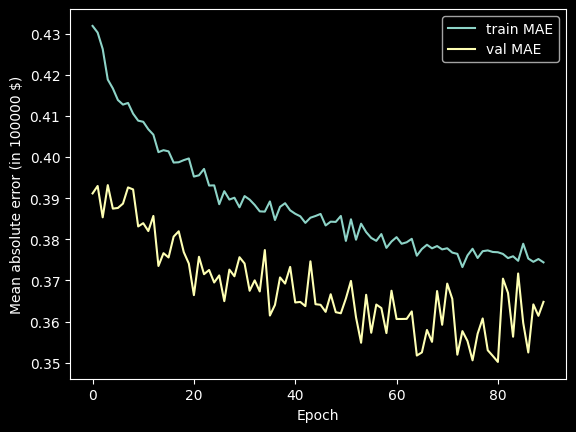

In [40]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

In [ ]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

In [41]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774712749.231238   15521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1265438__.21
I0000 00:00:1774712749.242762   15521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774712749.633999   15521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774712752.191532   15520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1265438__.21
I0000 00:00:1774712752.296908   15520 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain

Text(0, 0.5, 'Loss')

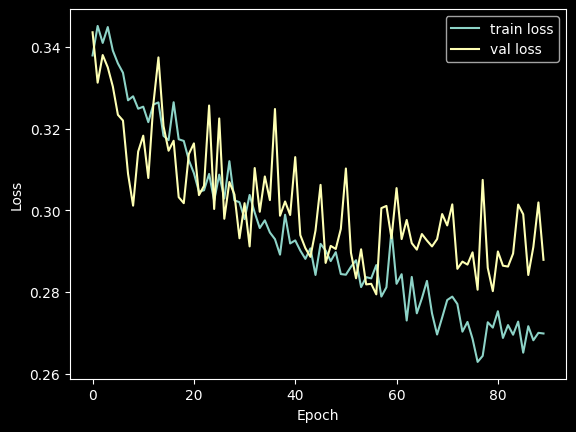

In [42]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

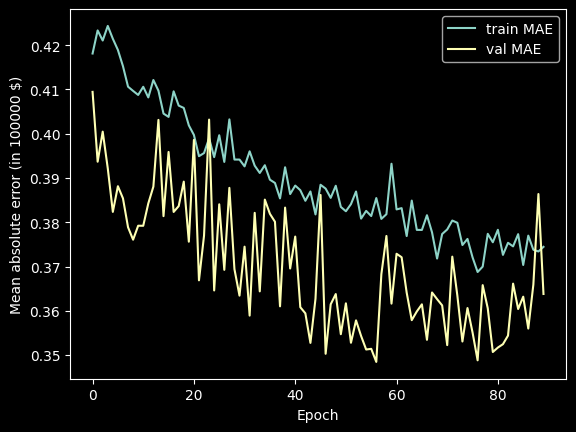

In [43]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

In [44]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2871 - mae: 0.3636
Test mean absolute error: 0.3636


In [45]:
y_pred_baseline = np.full_like(y_test, np.mean(y_train, axis=0))
mae_fn = MeanAbsoluteError()
mae_baseline = mae_fn(y_test, y_pred_baseline).numpy()
print(f'Mean baseline MAE: {mae_baseline:.4f}')

Mean baseline MAE: 0.9054
